In [ ]:
!pip -q install chembl_webresource_client
!pip -q install rdkit
!pip -q install pandas
!pip -q install requests
!pip install torch_geometric

In [ ]:
import requests
import pandas as pd
import time
from IPython.display import clear_output

print("Libraries loaded")

TARGET_ID = "CHEMBL203"
ACTIVITY_TYPES = ["IC50"]
PAGE_SIZE = 1000
MAX_RECORDS_PER_TYPE = 26600   # change this to 200, 500, 2000, etc.
OUTPUT_CSV = "EGFR_NSCLC_raw.csv"
CHEMBL_ACTIVITY_API = "https://www.ebi.ac.uk/chembl/api/data/activity.json"

print(f"Target         : {TARGET_ID}")
print(f"Activity types  : {ACTIVITY_TYPES}")
print(f"Page size       : {PAGE_SIZE}")
print(f"Max/type        : {MAX_RECORDS_PER_TYPE}")
print(f"Output          : {OUTPUT_CSV}")

resp = requests.get(
    CHEMBL_ACTIVITY_API,
    params={"target_chembl_id": TARGET_ID, "limit": 1, "format": "json"},
    timeout=30
)
resp.raise_for_status()
total_available = resp.json().get("page_meta", {}).get("total_count", 0)
print(f"Total activity records on CHEMBL203: {total_available:,}")

def fetch_limited(target_id, activity_type, page_size=1000, max_records=1000):
    records = []
    offset = 0
    total = None

    while len(records) < max_records:
        remaining = max_records - len(records)
        current_limit = min(page_size, remaining)

        params = {
            "target_chembl_id": target_id,
            "standard_type": activity_type,
            "limit": current_limit,
            "offset": offset,
            "format": "json",
        }

        try:
            resp = requests.get(CHEMBL_ACTIVITY_API, params=params, timeout=60)
            resp.raise_for_status()
            data = resp.json()
        except requests.exceptions.Timeout:
            print(f"Timeout at offset {offset} — retrying in 5s...")
            time.sleep(5)
            continue
        except Exception as e:
            print(f"Error: {e}")
            break

        batch = data.get("activities", [])
        if not batch:
            break

        if total is None:
            total = data.get("page_meta", {}).get("total_count", "?")
            print(f"  [{activity_type}] {total} records available")

        records.extend(batch)
        offset += len(batch)

        clear_output(wait=True)
        print(f"  [{activity_type}] {len(records)} / {max_records} fetched...")

        if len(batch) < current_limit:
            break

        time.sleep(0.3)

    print(f"  [{activity_type}] {len(records)} records done")
    return records[:max_records]

all_records = []
for atype in ACTIVITY_TYPES:
    print(f"\nFetching {atype}...")
    all_records.extend(fetch_limited(TARGET_ID, atype, PAGE_SIZE, MAX_RECORDS_PER_TYPE))

print(f"\nTotal records fetched: {len(all_records):,}")

df = pd.DataFrame(all_records)
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")

df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved '{OUTPUT_CSV}' — {len(df):,} rows, {len(df.columns)} columns")

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("EGFR_NSCLC_raw.csv")

keep_cols = [
    "activity_id",
    "assay_chembl_id",
    "assay_description",
    "assay_type",
    "canonical_smiles",
    "document_chembl_id",
    "document_year",
    "molecule_chembl_id",
    "molecule_pref_name",
    "parent_molecule_chembl_id",
    "pchembl_value",
    "potential_duplicate",
    "record_id",
    "src_id",
    "standard_flag",
    "standard_relation",
    "standard_text_value",
    "standard_type",
    "standard_units",
    "standard_value",
    "type",
    "units",
    "value",
]

keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
if "pchembl_value" in df.columns:
    df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")
if "document_year" in df.columns:
    df["document_year"] = pd.to_numeric(df["document_year"], errors="coerce")

df = df[df["molecule_chembl_id"].notna()].copy()
df = df[df["canonical_smiles"].notna()].copy()

if "standard_type" in df.columns:
    df["standard_type"] = df["standard_type"].astype(str).str.upper()

df = df[df["standard_type"].isin(["IC50"])].copy()
df = df[df["standard_value"].notna() & (df["standard_value"] > 0)].copy()

if "standard_relation" in df.columns:
    df = df[df["standard_relation"].fillna("=") == "="].copy()

df["pIC50"] = np.where(
    (df["standard_type"] == "IC50") & (df["standard_units"].astype(str).str.lower().isin(["nm", "um", "µm", "μm", "mm", "m"])),
    np.nan,
    np.nan
)

def pick_first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

agg_dict = {
    "canonical_smiles": pick_first_nonnull,
    "assay_chembl_id": pick_first_nonnull,
    "assay_description": pick_first_nonnull,
    "assay_type": pick_first_nonnull,
    "document_chembl_id": pick_first_nonnull,
    "document_year": "min",
    "molecule_pref_name": pick_first_nonnull,
    "parent_molecule_chembl_id": pick_first_nonnull,
    "pchembl_value": "median",
    "potential_duplicate": pick_first_nonnull,
    "record_id": pick_first_nonnull,
    "src_id": pick_first_nonnull,
    "standard_flag": pick_first_nonnull,
    "standard_relation": pick_first_nonnull,
    "standard_type": pick_first_nonnull,
    "standard_units": pick_first_nonnull,
    "standard_value": "median",
    "type": pick_first_nonnull,
    "units": pick_first_nonnull,
    "value": pick_first_nonnull,
}

group_cols = ["molecule_chembl_id"]
if "target_chembl_id" in df.columns:
    group_cols.append("target_chembl_id")
if "standard_type" in df.columns:
    group_cols.append("standard_type")

existing_agg = {k: v for k, v in agg_dict.items() if k in df.columns}
df_clean = df.groupby(group_cols, as_index=False).agg(existing_agg)

df_clean.to_csv("EGFR_NSCLC_raw_clean.csv", index=False)
print("Saved EGFR_NSCLC_raw_clean.csv")
print("Rows:", len(df_clean))
print("Unique molecules:", df_clean["molecule_chembl_id"].nunique())

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import inchi, AllChem
from concurrent.futures import ThreadPoolExecutor
from time import time
import json

RDLogger.DisableLog('rdApp.*')

INPUT_FILE = "EGFR_NSCLC_raw_clean.csv"
OUTPUT_FILE = "EGFR_NSCLC_thread_3d.csv"
NUM_WORKERS = 8

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")

smiles_col = "canonical_smiles" if "canonical_smiles" in df.columns else "Smiles"
if smiles_col not in df.columns:
    raise ValueError("No SMILES column found. Expected canonical_smiles or Smiles")

df = df.copy()
df[smiles_col] = df[smiles_col].astype(str).str.strip()
df = df[df[smiles_col].notna() & df[smiles_col].ne("")].copy()

for col in ["standard_value", "document_year", "pchembl_value"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

def safe_mol(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except:
        return None

def generate_inchi(smiles):
    mol = safe_mol(smiles)
    if mol is None:
        return None
    try:
        return inchi.MolToInchi(mol, options='-SNon')
    except:
        return None

def get_molecular_graph(smiles):
    mol = safe_mol(smiles)
    if mol is None:
        return None, None
    atom_types = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    bond_type_map = {
        Chem.BondType.SINGLE: 1,
        Chem.BondType.DOUBLE: 2,
        Chem.BondType.TRIPLE: 3,
        Chem.BondType.AROMATIC: 4
    }
    bond_edges = [
        [bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type_map.get(bond.GetBondType(), 1)]
        for bond in mol.GetBonds()
    ]
    return atom_types, bond_edges

def generate_3d_fast(smiles):
    try:
        mol = safe_mol(smiles)
        if mol is None:
            return None
        mol = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) != 0:
            return None
        return np.array(mol.GetConformer().GetPositions(), dtype=float)
    except:
        return None

def calc_pic50(row):
    if pd.isna(row.get("standard_value")):
        return np.nan
    if "standard_type" in row and str(row["standard_type"]).upper() != "IC50":
        return np.nan
    unit = str(row.get("standard_units", "")).lower().strip()
    value = row["standard_value"]
    if pd.isna(value) or value <= 0:
        return np.nan
    if unit == "nm":
        molar = value * 1e-9
    elif unit in ["um", "µm", "μm"]:
        molar = value * 1e-6
    elif unit == "mm":
        molar = value * 1e-3
    elif unit == "m":
        molar = value
    else:
        return np.nan
    return -np.log10(molar)

t0 = time()

print("Step 1: pIC50...")
df["pIC50"] = df.apply(calc_pic50, axis=1)
df = df.dropna(subset=["pIC50"]).copy()
print(f"After pIC50: {len(df)} rows")

print("Step 2: InChI...")
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
    df["InChI"] = list(ex.map(generate_inchi, df[smiles_col]))
df = df.dropna(subset=["InChI"]).copy()

print("Step 3: Graph...")
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
    graph_data = list(ex.map(get_molecular_graph, df[smiles_col]))
df["AtomNodes"] = [json.dumps(x[0]) if x[0] is not None else None for x in graph_data]
df["BondEdges"] = [json.dumps(x[1]) if x[1] is not None else None for x in graph_data]
df = df.dropna(subset=["AtomNodes", "BondEdges"]).copy()

print("Step 4: 3D...")
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
    df["3D_Conformer"] = list(ex.map(generate_3d_fast, df[smiles_col]))
df = df.dropna(subset=["3D_Conformer"]).copy()

df["3D_Conformer"] = df["3D_Conformer"].apply(lambda x: json.dumps(x.tolist()) if x is not None else None)
df.to_csv(OUTPUT_FILE, index=False)

print(f"Saved {len(df)} rows to {OUTPUT_FILE}")
print(f"Total time: {time()-t0:.1f}s")

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen, Lipinski
from time import time

INPUT_FILE = "EGFR_NSCLC_thread_3d.csv"
DESCRIPTOR_FILE = "descriptors.csv"

print("Loading file:", INPUT_FILE)
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")

# Find SMILES column
smiles_col = None
for c in ["smiles", "canonical_smiles", "Smiles"]:
    if c in df.columns:
        smiles_col = c
        break

if smiles_col is None:
    raise ValueError("No SMILES column found. Expected 'smiles', 'canonical_smiles', or 'Smiles'.")

print(f"Using SMILES column: {smiles_col}")

# Process molecules
rows = []
start = time()

for i, row in df.iterrows():
    mol_id = row.get("molecule_chembl_id", row.get("Molecule ChEMBL ID", f"mol_{i}"))
    smiles = row[smiles_col]
    
    if pd.isna(smiles) or smiles is None:
        continue
    
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        continue
    
    rows.append({
        "molecule_id": mol_id,
        "smiles": str(smiles),
        "mol_wt": Descriptors.MolWt(mol),
        "tpsa": rdMolDescriptors.CalcTPSA(mol),
        "logp": Crippen.MolLogP(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
        "ring_count": rdMolDescriptors.CalcNumRings(mol),
        "fraction_csp3": rdMolDescriptors.CalcFractionCSP3(mol)
    })
    
    if i % 5000 == 0 and i > 0:
        print(f"Processed {i}/{len(df)}...")

desc_df = pd.DataFrame(rows)
desc_df.to_csv(DESCRIPTOR_FILE, index=False)

elapsed = time() - start

print("")
print("=" * 60)
print("DONE!")
print("=" * 60)
print(f"Saved: {DESCRIPTOR_FILE}")
print(f"Rows: {len(desc_df)}")
print(f"Columns: {len(desc_df.columns)}")
print(f"Time: {elapsed:.1}s ({elapsed/60:.1} minutes)")
print(f"Columns: {desc_df.columns.tolist()}")

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from time import time

DESCRIPTOR_FILE = "descriptors.csv"
OUTPUT_FILE = "descriptors_with_fingerprints.csv"

print(f"Loading {DESCRIPTOR_FILE}...")
df = pd.read_csv(DESCRIPTOR_FILE)
print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")

# Find SMILES column
smiles_col = None
for c in ["smiles", "canonical_smiles", "Smiles"]:
    if c in df.columns:
        smiles_col = c
        break

if smiles_col is None:
    raise ValueError("No SMILES column found. Expected 'smiles', 'canonical_smiles', or 'Smiles'.")

print(f"Using SMILES column: {smiles_col}")

# Setup Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Process molecules
rows = []
start = time()

for i, row in df.iterrows():
    smiles = row[smiles_col]
    
    if pd.isna(smiles) or smiles is None:
        continue
    
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        continue
    
    out = row.to_dict()
    
    # Morgan fingerprint
    morgan_fp = morgan_gen.GetFingerprint(mol)
    morgan_arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(morgan_fp, morgan_arr)
    for j, bit in enumerate(morgan_arr):
        out[f"morgan_{j}"] = int(bit)
    
    # MACCS fingerprint
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)
    maccs_arr = np.zeros((167,), dtype=int)
    DataStructs.ConvertToNumpyArray(maccs_fp, maccs_arr)
    for j in range(1, 167):
        out[f"maccs_{j}"] = int(maccs_arr[j])
    
    rows.append(out)
    
    if i % 5000 == 0 and i > 0:
        print(f"Processed {i}/{len(df)}...")

final_df = pd.DataFrame(rows)
final_df.to_csv(OUTPUT_FILE, index=False)

elapsed = time() - start

print("")
print("=" * 60)
print("DONE!")
print("=" * 60)
print(f"Saved: {OUTPUT_FILE}")
print(f"Rows: {len(final_df)}")
print(f"Columns: {len(final_df.columns)}")
print(f"Time: {elapsed:.1}s ({elapsed/60:.1} minutes)")

# Show fingerprint columns
fp_cols = [col for col in final_df.columns if col.startswith("morgan_") or col.startswith("maccs_")]
print(f"FP columns: {len(fp_cols)} (first 5: {fp_cols[:5]})")

In [ ]:
import pandas as pd
import numpy as np

activity = pd.read_csv("EGFR_NSCLC_thread_3d.csv")
features = pd.read_csv("descriptors_with_fingerprints.csv")

# Make sure pIC50 is numeric
activity["pIC50"] = pd.to_numeric(activity["pIC50"], errors="coerce")
activity = activity.dropna(subset=["pIC50", "molecule_chembl_id"])

# Define active from pIC50
# pIC50 >= 7 means IC50 <= 1000 nM
activity["active"] = (activity["pIC50"] >= 7).astype(int)

# Keep only needed columns and remove duplicate molecules
activity = activity[["molecule_chembl_id", "active"]].drop_duplicates()

# Standardize merge key
features = features.rename(columns={"molecule_id": "molecule_chembl_id"})

# Merge feature table with labels
df = features.merge(activity, on="molecule_chembl_id", how="inner")

# Save
df.to_csv("module4_all_feature_ready.csv", index=False)

print(df["active"].value_counts())
print("Saved: module4_all_feature_ready.csv")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

INPUT_FILE = "module4_all_feature_ready.csv"   # change if needed

df = pd.read_csv(INPUT_FILE)

fp_cols = [c for c in df.columns if c.startswith("morgan_")]
if not fp_cols:
    raise ValueError("No Morgan fingerprint columns found in the input file.")

target_col = None
for c in ["active", "label", "activity", "is_active"]:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError("No label column found. Add one of: active, label, activity, is_active")

X = df[fp_cols]
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

test_ids = df.loc[X_test.index, "molecule_id"].values if "molecule_id" in df.columns else X_test.index
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive class ratio:", y.mean())

In [ ]:
# Install xgboost and lightgbm in current cell
!pip install xgboost lightgbm

# Verify installation
import xgboost
import lightgbm
print(f"XGBoost version: {xgboost.__version__}")
print(f"LightGBM version: {lightgbm.__version__}")

In [ ]:
import pandas as pd
import warnings
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", message="No further splits with positive gain")

main_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

comparison_models = {
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=10,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}

results = []
pred_df = pd.DataFrame({
    "molecule_id": test_ids,
    "true_label": y_test.values
})

for name, model in main_models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "role": "main",
        "roc_auc": roc_auc_score(y_test, prob),
        "accuracy": accuracy_score(y_test, pred)
    })

    pred_df[f"{name}_prob_active"] = prob
    pred_df[f"{name}_pred"] = pred

    print(f"\n=== {name} ===")
    print("ROC-AUC:", roc_auc_score(y_test, prob))
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "role": "comparison",
        "roc_auc": roc_auc_score(y_test, prob),
        "accuracy": accuracy_score(y_test, pred)
    })

    pred_df[f"{name}_prob_active"] = prob
    pred_df[f"{name}_pred"] = pred

    print(f"\n=== {name} ===")
    print("ROC-AUC:", roc_auc_score(y_test, prob))
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

results_df = pd.DataFrame(results)
main_results_df = results_df[results_df["role"] == "main"].sort_values("roc_auc", ascending=False)
comparison_results_df = results_df[results_df["role"] == "comparison"].sort_values("roc_auc", ascending=False)

main_results_df.to_csv("module4_main_model_metrics.csv", index=False)
comparison_results_df.to_csv("module4_comparison_model_metrics.csv", index=False)
pred_df.to_csv("module4_test_predictions.csv", index=False)

best_main_model = main_results_df.iloc[0]["model"]
print("\nBest main model:", best_main_model)
print("\nSaved: module4_main_model_metrics.csv")
print("Saved: module4_comparison_model_metrics.csv")
print("Saved: module4_test_predictions.csv")

In [ ]:
# Install PyTorch in current Jupyter environment
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --no-cache-dir
!pip install torch-geometric rdkit

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

In [ ]:
import pandas as pd
import torch
import numpy as np
from ast import literal_eval  # Added
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.nn import MessagePassing
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 1. LOAD DATA
# ============================================
INPUT_FILE = "EGFR_NSCLC_thread_3d.csv"

print("Loading data...")
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")

# Convert string lists to actual lists
print("Converting AtomNodes and BondEdges from strings to lists...")
df["AtomNodes"] = df["AtomNodes"].apply(literal_eval)
df["BondEdges"] = df["BondEdges"].apply(literal_eval)

# Find pIC50 column
pic50_col = next((c for c in ["pIC50", "pic50", "PIC50"] if c in df.columns), None)
if not pic50_col:
    raise ValueError("No pIC50 column")

df[pic50_col] = pd.to_numeric(df[pic50_col], errors="coerce")
df = df.dropna(subset=["AtomNodes", "BondEdges", pic50_col]).copy()
print(f"Cleaned: {len(df)} rows")

# ============================================
# 2. BUILD GRAPHS (rest same)
# ============================================
def mol_to_graph_from_lists(atom_nodes, bond_edges, y_value, mol_id=None, smiles=None):
    x = torch.tensor([[float(atom)] for atom in atom_nodes], dtype=torch.float)
    
    edge_indices = []
    for i, j, bond_type in bond_edges:
        edge_indices.append([i, j])
        edge_indices.append([j, i])
    
    if not edge_indices:
        return None
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor([[float(bond_type)] for _, _, bond_type in bond_edges], dtype=torch.float)
    edge_attr = edge_attr.repeat_interleave(2, dim=0)
    
    y = torch.tensor([float(y_value)], dtype=torch.float)
    
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    if mol_id:
        data.molecule_id = str(mol_id)
    if smiles:
        data.smiles = str(smiles)
    return data

print("\nBuilding graphs...")
graphs = []
for i, row in df.iterrows():
    mol_id = row.get("molecule_chembl_id", row.get("Molecule ChEMBL ID", f"mol_{i}"))
    smiles = row.get("smiles", row.get("Smiles", None))
    
    g = mol_to_graph_from_lists(row["AtomNodes"], row["BondEdges"], row[pic50_col], mol_id, smiles)
    if g:
        graphs.append(g)
    
    if i % 5000 == 0 and i > 0:
        print(f"  {i}/{len(df)}...")

print(f"Graphs: {len(graphs)}")
print(f"Node features: {graphs[0].num_node_features}")

# ... (rest of code - splitting, models, training - same as before) ...

In [ ]:
# ============================================
# COMPLETE MPNN + GCN TRAINING (ALL IN ONE CELL)
# ============================================

import pandas as pd
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.nn import MessagePassing
import warnings
warnings.filterwarnings("ignore")

# ============================================
# GPU SETUP WITH MEMORY PROTECTION
# ============================================
# Check GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"\nGPU Available: {torch.cuda.get_device_name(0)}")
    # IMPORTANT: Limit GPU memory usage to 80% to prevent crashes
    torch.cuda.set_per_process_memory_fraction(0.8, 0)
else:
    device = torch.device("cpu")
    print("\nNo GPU available. Training will run on CPU.")

# ============================================
# SPLIT DATA
# ============================================
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)

# IMPORTANT: Set num_workers=0 for Windows/WSL to prevent crashes
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False, num_workers=0)

print(f"\nTrain: {len(train_graphs)}, Test: {len(test_graphs)}")

# ============================================
#DEFINE MODELS
# ============================================
class GCNRegressor(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin2 = nn.Linear(hidden_dim // 2, 1)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        return self.lin2(x).view(-1)

class MPNNConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='mean')
        self.lin = nn.Linear(in_channels, out_channels)
    
    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=self.lin(x))
    
    def message(self, x_j, x_i):
        return x_j

class MPNNRegressor(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64):
        super().__init__()
        self.conv1 = MPNNConv(num_node_features, hidden_dim)
        self.conv2 = MPNNConv(hidden_dim, hidden_dim)
        self.conv3 = MPNNConv(hidden_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin2 = nn.Linear(hidden_dim // 2, 1)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.lin1(x))
        return self.lin2(x).view(-1)

# ============================================
# EVALUATION FUNCTION
# ============================================
def evaluate(model, loader, device, criterion):
    model.eval()
    preds, targets, total_loss = [], [], 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)  # Move batch to GPU
            pred = model(batch)
            loss = criterion(pred, batch.y.view(-1))
            total_loss += loss.item() * batch.num_graphs
            preds.extend(pred.cpu().numpy())  # Move back to CPU for numpy
            targets.extend(batch.y.view(-1).cpu().numpy())
    
    preds, targets = np.array(preds), np.array(targets)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)
    return total_loss / len(loader.dataset), rmse, r2, preds, targets

# ============================================
# TRAIN
# ============================================
print(f"\nDevice: {device}")

num_features = graphs[0].num_node_features

# Move models to GPU
model_gcn = GCNRegressor(num_features).to(device)
model_mpnn = MPNNRegressor(num_features).to(device)

optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.001)
optimizer_mpnn = torch.optim.Adam(model_mpnn.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_model(model, optimizer, name, epochs=50):
    print(f"\n{'='*60}")
    print(f"TRAINING {name}")
    print(f"{'='*60}")
    
    best_r2 = -float('inf')
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        
        for batch in train_loader:
            batch = batch.to(device)  # Move batch to GPU
            optimizer.zero_grad()
            pred = model(batch)
            loss = criterion(pred, batch.y.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        
        train_loss = total_loss / len(train_loader.dataset)
        test_loss, rmse, r2, _, _ = evaluate(model, test_loader, device, criterion)
        
        if r2 > best_r2:
            best_r2 = r2
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | Train: {train_loss:.4f} | Test: {test_loss:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
        
        # Optional: Clear cache every 10 epochs to prevent memory issues
        if epoch % 10 == 0:
            torch.cuda.empty_cache()
    
    return best_r2

gcn_r2 = train_model(model_gcn, optimizer_gcn, "GCN")
mpnn_r2 = train_model(model_mpnn, optimizer_mpnn, "MPNN")

# ============================================
# SAVE
# ============================================
def save_predictions(model, loader, device, filename, model_name):
    model.eval()
    rows = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)  # Move to GPU
            pred = model(batch).cpu().numpy()  # Move predictions back to CPU
            true = batch.y.view(-1).cpu().numpy()
            
            for i in range(len(pred)):
                rows.append({
                    "molecule_id": batch.molecule_id[i] if hasattr(batch, "molecule_id") else None,
                    "smiles": batch.smiles[i] if hasattr(batch, "smiles") else None,
                    "true_pIC50": float(true[i]),
                    "predicted_pIC50": float(pred[i]),
                    "model": model_name
                })
    
    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"Saved: {filename}")

save_predictions(model_gcn, test_loader, device, "module5_GCN_predictions.csv", "GCN")
save_predictions(model_mpnn, test_loader, device, "module5_MPNN_predictions.csv", "MPNN")

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"GCN:  R2 = {gcn_r2:.4f}")
print(f"MPNN: R2 = {mpnn_r2:.4f}")
print(f"\nBest: {('GCN' if gcn_r2 > mpnn_r2 else 'MPNN')}")

# ============================================
# GPU USAGE VERIFICATION
# ============================================
print("\n" + "=" * 60)
print("GPU MEMORY USAGE")
print("=" * 60)
if torch.cuda.is_available():
    print(f"Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
    print(f"Reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
print("\n DONE!")

In [ ]:
!git clone https://github.com/swansonk14/admet_ai.git
!pip install admet-ai

In [ ]:
import pandas as pd
from admet_ai import ADMETModel

input_df = pd.read_csv("EGFR_NSCLC_thread_3d.csv")

input_df = input_df.dropna(subset=["molecule_chembl_id", "canonical_smiles"]).copy()
input_df["canonical_smiles"] = input_df["canonical_smiles"].astype(str).str.strip()

smiles_list = input_df["canonical_smiles"].tolist()

model = ADMETModel()
all_preds = model.predict(smiles=smiles_list)

pred_df = all_preds.reset_index().copy()

if "index" in pred_df.columns:
    pred_df = pred_df.rename(columns={"index": "canonical_smiles"})
elif "smiles" in pred_df.columns:
    pred_df = pred_df.rename(columns={"smiles": "canonical_smiles"})

if "canonical_smiles" not in pred_df.columns:
    raise KeyError("Prediction output does not contain a SMILES key column")

base_df = input_df[["molecule_chembl_id", "canonical_smiles", "pIC50"]].copy()

out = base_df.merge(
    pred_df,
    on="canonical_smiles",
    how="inner",
    validate="m:1"
)

out.to_csv("module6_admet.csv", index=False)
print("Saved module6_admet.csv")
print("Rows:", len(out))
print("Columns:", len(out.columns))

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("module6_admet.csv")

df.columns = df.columns.str.strip()

smiles_col = None
if "canonical_smiles" in df.columns:
    smiles_col = "canonical_smiles"
elif "smiles" in df.columns:
    smiles_col = "smiles"
else:
    raise KeyError(f"No SMILES column found. Available columns: {df.columns.tolist()}")

out = pd.DataFrame()
out["molecule_chembl_id"] = df["molecule_chembl_id"]
out["smiles"] = df[smiles_col]
out["pic50"] = pd.to_numeric(df["pIC50"], errors="coerce").round(2)

if "Solubility_AqSolDB" in df.columns:
    out["solubility"] = pd.to_numeric(df["Solubility_AqSolDB"], errors="coerce").round(2)
else:
    out["solubility"] = np.nan

tox_cols = ["AMES", "ClinTox", "DILI", "hERG"]
for col in tox_cols:
    if col in df.columns:
        out[f"toxicity_{col}"] = pd.to_numeric(df[col], errors="coerce").round(2)

if "Clearance_Hepatocyte_AZ" in df.columns:
    out["clearance_hepatocyte"] = pd.to_numeric(df["Clearance_Hepatocyte_AZ"], errors="coerce").round(2)
else:
    out["clearance_hepatocyte"] = np.nan

if "Clearance_Microsome_AZ" in df.columns:
    out["clearance_microsome"] = pd.to_numeric(df["Clearance_Microsome_AZ"], errors="coerce").round(2)
else:
    out["clearance_microsome"] = np.nan

if "Half_Life_Obach" in df.columns:
    out["half_life"] = pd.to_numeric(df["Half_Life_Obach"], errors="coerce").round(2)
else:
    out["half_life"] = np.nan

out.to_csv("module6_output.csv", index=False)

print(f"Saved module6_output.csv with {len(out)} rows")
print(out.head())

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Contrib.SA_Score import sascorer


# Load data
df = pd.read_csv("module6_admet.csv")

# DON'T lowercase - use original column names
# df.columns = df.columns.str.strip().str.lower()  # REMOVE THIS LINE

for col in ["pIC50", "Solubility_AqSolDB", "AMES", "ClinTox", "DILI", "hERG"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

def minmax(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return pd.Series(0.5, index=s.index)
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mn == mx:
        return pd.Series(0.5, index=s.index)
    return (s - mn) / (mx - mn)

def sa_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return sascorer.calculateScore(mol)

# Raw columns - use EXACT column names
tracking = df[["molecule_chembl_id", "canonical_smiles", "pIC50"]].copy()
tracking.columns = ["molecule_chembl_id", "smiles", "pic50"]  # Rename for consistency

if "Solubility_AqSolDB" in df.columns:
    tracking["solubility_raw"] = df["Solubility_AqSolDB"]
else:
    tracking["solubility_raw"] = np.nan

tox_candidates = ["AMES", "ClinTox", "DILI", "hERG"]
tox_col = next((c for c in tox_candidates if c in df.columns), None)
if tox_col is not None:
    tracking["toxicity_raw"] = df[tox_col]
    tracking["toxicity_source"] = tox_col
else:
    tracking["toxicity_raw"] = np.nan
    tracking["toxicity_source"] = None

if "canonical_smiles" in df.columns:
    tracking["sa_raw"] = df["canonical_smiles"].apply(sa_score)
else:
    tracking["sa_raw"] = np.nan

# Normalized component scores
tracking["potency_score"] = minmax(tracking["pic50"])
tracking["solubility_score"] = minmax(tracking["solubility_raw"])
tracking["toxicity_score"] = 1 - minmax(tracking["toxicity_raw"]) if tracking["toxicity_raw"].notna().any() else 0.5
tracking["sa_score"] = 1 - minmax(tracking["sa_raw"]) if tracking["sa_raw"].notna().any() else 0.5

# Final score
tracking["final_score"] = (
    0.4 * tracking["potency_score"].fillna(0.5) +
    0.2 * tracking["solubility_score"].fillna(0.5) +
    0.2 * tracking["toxicity_score"].fillna(0.5) +
    0.2 * tracking["sa_score"].fillna(0.5)
)

# Save score tracking table
tracking.to_csv("module7_score_tracking.csv", index=False)

# Ranked output
ranked = tracking.sort_values("final_score", ascending=False).reset_index(drop=True)
ranked.to_csv("module7_ranked_molecules.csv", index=False)

print(f"Saved module7_score_tracking.csv with {len(tracking)} rows")
print(f"Saved module7_ranked_molecules.csv")
print("\nTop 10 molecules:")
print(ranked.head(10))

In [ ]:
!pip install rdkit pandas numpy -q

import pandas as pd
import random
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Load dataset
df = pd.read_csv("EGFR_NSCLC_thread_3d.csv")
smiles_col = "canonical_smiles"
seed_smiles = df[smiles_col].tolist()

print(f"Loaded {len(seed_smiles)} molecules")

# Better scoring function
def score_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    qed = QED.qed(mol)
    
    # EGFR inhibitor properties
    mw_score = min(1.0, max(0.0, (600 - mw) / 400)) if 200 <= mw <= 600 else 0
    logp_score = 1.0 if logp < 5 else max(0, 1 - (logp - 5) / 5)
    hbd_score = 1.0 if hbd <= 5 else max(0, 1 - (hbd - 5) / 5)
    hba_score = 1.0 if hba <= 10 else max(0, 1 - (hba - 10) / 10)
    
    return 0.3 * mw_score + 0.2 * logp_score + 0.15 * hbd_score + 0.15 * hba_score + 0.2 * qed

# Better mutation operators
def mutate_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    
    mutations = []
    
    # 1. Add atom (C, N, O, F, Cl)
    for atom_type in [6, 7, 8, 9, 17]:  # C, N, O, F, Cl
        rw = Chem.RWMol(mol)
        try:
            atom_idx = random.randint(0, rw.GetNumAtoms() - 1)
            new_atom = Chem.Atom(atom_type)
            new_idx = rw.AddAtom(new_atom)
            rw.AddBond(atom_idx, new_idx, Chem.BondType.SINGLE)
            Chem.SanitizeMol(rw.GetMol())
            mutations.append(Chem.MolToSmiles(rw.GetMol()))
        except:
            pass
    
    # 2. Replace atom with similar one
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() in [6, 7, 8]:
            rw = Chem.RWMol(mol)
            try:
                new_atom = Chem.Atom(random.choice([6, 7, 8]))
                rw.RemoveAtom(atom.GetIdx())
                new_idx = rw.AddAtom(new_atom)
                Chem.SanitizeMol(rw.GetMol())
                mutations.append(Chem.MolToSmiles(rw.GetMol()))
            except:
                pass
    
    # 3. Add common groups (OH, CH3, F)
    groups = [
        Chem.MolFromSmiles("O"),   # OH
        Chem.MolFromSmiles("C"),   # CH3
        Chem.MolFromSmiles("F"),   # F
    ]
    
    for group in groups:
        rw = Chem.RWMol(mol)
        try:
            atom_idx = random.randint(0, rw.GetNumAtoms() - 1)
            group_atom = group.GetAtomWithIdx(0)
            new_idx = rw.AddAtom(group_atom)
            rw.AddBond(atom_idx, new_idx, Chem.BondType.SINGLE)
            Chem.SanitizeMol(rw.GetMol())
            mutations.append(Chem.MolToSmiles(rw.GetMol()))
        except:
            pass
    
    return mutations if mutations else None

# Optimize with multiple mutations per seed
results = []
optimized_count = 0

for i, smi in enumerate(seed_smiles[:500]):  # Use 500 seeds
    mutations = mutate_smiles(smi)
    if mutations:
        old_score = score_molecule(smi)
        
        for new_smi in mutations:
            new_score = score_molecule(new_smi)
            # Accept if score improves by at least 0.01
            if new_score > old_score + 0.01:
                results.append([smi, new_smi, old_score, new_score])
                optimized_count += 1
                break  # Take best mutation for this seed

# Save results
out_df = pd.DataFrame(results, columns=["original_smiles", "optimized_smiles", "old_score", "new_score"])
out_df = out_df.sort_values("new_score", ascending=False)
out_df.to_csv("module9_chembl_optimized.csv", index=False)

print(f"\nOptimized {len(results)} molecules from {optimized_count} successful mutations")
print(f"Success rate: {len(results)/500*100:.1f}%")
print("\nTop 20 optimized molecules:")
print(out_df.head(20))
print(f"\nScore improvement: {out_df['new_score'].mean() - out_df['old_score'].mean():.3f} avg")
print("\nSaved: module9_chembl_optimized.csv")

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

INPUT_FILE = 'EGFR_NSCLC_raw_clean.csv'
CLEAN_FILE = 'module10_EGFR_cleaned.csv'
DUP_FILE = 'module10_EGFR_duplicates.csv'
NOISE_FILE = 'module10_EGFR_assay_noise.csv'
CLIFF_FILE = 'module10_EGFR_activity_cliffs.csv'
SUMMARY_FILE = 'module10_EGFR_summary.csv'

# Load
try:
    df = pd.read_csv(INPUT_FILE)
except Exception:
    df = pd.read_csv(INPUT_FILE, sep=';')

df.columns = df.columns.str.strip()
low = {c.lower(): c for c in df.columns}

smiles_col = low.get('canonical_smiles')
id_col = low.get('molecule_chembl_id')
pchembl_col = next((c for c in df.columns if 'pch' in c.lower() and 'value' in c.lower()), None)
std_val_col = low.get('standard value')
std_units_col = low.get('standard units')
target_col = low.get('target chembl id')
assay_col = low.get('assay chembl id')

print(f"Loaded: {INPUT_FILE}")
print(f"Rows: {len(df)}")
print(f"SMILES: {smiles_col}")
print(f"ID: {id_col}")
print(f"pChEMBL: {pchembl_col}")
print(f"Standard value: {std_val_col}")

# Clean
work = df[df[smiles_col].notna() & df[id_col].notna()].copy()
work[smiles_col] = work[smiles_col].astype(str).str.strip()

def valid_smiles(s):
    try:
        return Chem.MolFromSmiles(str(s)) is not None
    except:
        return False

work = work[work[smiles_col].apply(valid_smiles)].copy()

# Standardized activity
activity_source = None
if pchembl_col and work[pchembl_col].notna().sum() > 0:
    work[pchembl_col] = pd.to_numeric(work[pchembl_col], errors='coerce')
    work['activity_std'] = work[pchembl_col]
    activity_source = 'pChEMBL Value'
elif std_val_col and work[std_val_col].notna().sum() > 0:
    work[std_val_col] = pd.to_numeric(work[std_val_col], errors='coerce')
    if std_units_col:
        units = work[std_units_col].astype(str).str.lower()
        work['activity_std'] = np.where(
            units.str.contains('nm', na=False),
            -np.log10(work[std_val_col] / 1e9),
            np.nan
        )
        activity_source = 'Standard Value -> pIC50 (nM only)'
    else:
        work['activity_std'] = np.nan
else:
    work['activity_std'] = np.nan

# Restrict to comparable rows
if target_col:
    work = work[work[target_col].notna()].copy()
if assay_col:
    work = work[work[assay_col].notna()].copy()

act = work[work['activity_std'].notna()].copy()
act = act.drop_duplicates(subset=[smiles_col, id_col, 'activity_std']).reset_index(drop=True)

# Save cleaned
work.to_csv(CLEAN_FILE, index=False)

# Duplicates
dup_df = work[work.duplicated(subset=[smiles_col], keep=False)].copy()
dup_df.to_csv(DUP_FILE, index=False)

# Assay noise
noise_rows = []
for smi, g in act.groupby(smiles_col):
    vals = g['activity_std'].astype(float)
    if len(vals) > 1:
        rng = float(vals.max() - vals.min())
        if rng >= 1.0:
            noise_rows.append({
                'molecule_chembl_id': g[id_col].iloc[0],
                'smiles': smi,
                'n_replicates': len(vals),
                'activity_min': vals.min(),
                'activity_max': vals.max(),
                'activity_range': rng
            })
noise_df = pd.DataFrame(noise_rows)
noise_df.to_csv(NOISE_FILE, index=False)

# Activity cliffs
cliff_rows = []
sample_n = min(1000, len(act))

if sample_n >= 2:
    s = act.head(sample_n).copy().reset_index(drop=True)
    fps, keep_idx = [], []

    for i, r in s.iterrows():
        mol = Chem.MolFromSmiles(r[smiles_col])
        if mol is None:
            continue
        fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
        keep_idx.append(i)

    s = s.loc[keep_idx].reset_index(drop=True)
    fps = [fps[i] for i in range(len(s))]

    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            diff = abs(float(s.loc[i, 'activity_std']) - float(s.loc[j, 'activity_std']))
            if sim >= 0.75 and diff >= 1.0:
                cliff_rows.append({
                    'id_1': s.loc[i, id_col],
                    'smiles_1': s.loc[i, smiles_col],
                    'activity_1': s.loc[i, 'activity_std'],
                    'id_2': s.loc[j, id_col],
                    'smiles_2': s.loc[j, smiles_col],
                    'activity_2': s.loc[j, 'activity_std'],
                    'similarity': sim,
                    'activity_diff': diff,
                    'target_1': s.loc[i, target_col] if target_col else None,
                    'target_2': s.loc[j, target_col] if target_col else None,
                    'assay_1': s.loc[i, assay_col] if assay_col else None,
                    'assay_2': s.loc[j, assay_col] if assay_col else None
                })

cliff_df = pd.DataFrame(cliff_rows)
cliff_df = cliff_df.sort_values(['activity_diff', 'similarity'], ascending=[False, False]) if len(cliff_df) else cliff_df
cliff_df.to_csv(CLIFF_FILE, index=False)

# Summary
summary = pd.DataFrame([{
    'input_rows': len(df),
    'clean_rows': len(work),
    'activity_rows': len(act),
    'duplicate_smiles_rows': len(dup_df),
    'noise_cases': len(noise_df),
    'activity_cliffs': len(cliff_df),
    'activity_source': activity_source
}])
summary.to_csv(SUMMARY_FILE, index=False)

print("\nSummary:")
print(summary.to_string(index=False))
print("\nTop activity cliffs:")
print(cliff_df.head(10).to_string(index=False) if len(cliff_df) else "None found")

print("\nSaved files:")
print(CLEAN_FILE)
print(DUP_FILE)
print(NOISE_FILE)
print(CLIFF_FILE)
print(SUMMARY_FILE)

In [ ]:
import pandas as pd

feat = pd.read_csv("module4_all_feature_ready.csv")
meta = pd.read_csv("EGFR_NSCLC_thread_3d.csv")

feat.columns = feat.columns.str.strip()
meta.columns = meta.columns.str.strip()

if "canonical_smiles" in meta.columns and "smiles" not in meta.columns:
    meta = meta.rename(columns={"canonical_smiles": "smiles"})

meta_keep = [c for c in ["molecule_chembl_id", "smiles", "document_year", "pIC50"] if c in meta.columns]
meta = meta[meta_keep].copy()

feat = feat.drop_duplicates(subset=["molecule_chembl_id"], keep="first").copy()
meta = meta.drop_duplicates(subset=["molecule_chembl_id"], keep="first").copy()

df = feat.merge(meta, on="molecule_chembl_id", how="left", suffixes=("", "_meta"))

if "smiles_meta" in df.columns:
    df["smiles"] = df["smiles"].fillna(df["smiles_meta"])
    df = df.drop(columns=["smiles_meta"])

base_cols = ["molecule_chembl_id", "smiles", "document_year", "pIC50", "active"]
physchem_cols = [c for c in ["mol_wt", "tpsa", "logp", "hba", "hbd", "rotatable_bonds", "ring_count", "fraction_csp3"] if c in df.columns]
morgan_cols = [c for c in df.columns if c.startswith("morgan_")]
maccs_cols = [c for c in df.columns if c.startswith("maccs_")]

keep_cols = [c for c in base_cols if c in df.columns] + physchem_cols + morgan_cols + maccs_cols
df = df[keep_cols].copy()

if "document_year" in df.columns:
    df["document_year"] = pd.to_numeric(df["document_year"], errors="coerce")
if "pIC50" in df.columns:
    df["pIC50"] = pd.to_numeric(df["pIC50"], errors="coerce")

df = df.dropna(subset=["molecule_chembl_id", "smiles", "pIC50", "active"]).copy()

df.to_csv("module11_validation_ready.csv", index=False)

print("Saved module11_validation_ready.csv")
print("Rows:", len(df))
print("Columns:", len(df.columns))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def load_dataset(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    print(f"Loaded: {len(df)} molecules")

    if "pIC50" not in df.columns:
        raise KeyError("pIC50 column not found")

    if "smiles" not in df.columns:
        if "canonical_smiles" in df.columns:
            df = df.rename(columns={"canonical_smiles": "smiles"})
        else:
            raise KeyError("No smiles/canonical_smiles column found")

    df["pIC50"] = pd.to_numeric(df["pIC50"], errors="coerce")
    df = df.dropna(subset=["pIC50", "smiles"]).copy()
    df["active"] = (df["pIC50"] >= 6.0).astype(int)
    df["index"] = np.arange(len(df))

    candidate_features = [
        "mol_wt", "tpsa", "logp", "hba", "hbd",
        "rotatable_bonds", "ring_count", "fraction_csp3",
        "morgan_0", "morgan_1", "morgan_2", "morgan_3",
        "maccs_1", "maccs_2", "maccs_3"
    ]

    feature_cols = [c for c in candidate_features if c in df.columns]

    if not feature_cols:
        raise ValueError("No valid numeric feature columns found")

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df = df.dropna(subset=["active"]).copy()
    print(f"Active: {df['active'].sum()} ({df['active'].mean()*100:.1f}%)")
    print(f"Using features: {feature_cols}")

    return df, feature_cols

def get_scaffold(smi):
    return smi[:20] if isinstance(smi, str) and len(smi) >= 20 else str(smi)

def scaffold_split(df):
    df = df.copy()
    df["scaffold"] = df["smiles"].apply(get_scaffold)
    groups = df.groupby("scaffold").indices
    scaffolds = sorted(groups.items(), key=lambda x: len(x[1]), reverse=True)

    train_idx, valid_idx, test_idx = [], [], []
    n = len(df)

    for _, idx in scaffolds:
        idx_list = list(idx)
        if len(train_idx) + len(idx_list) <= 0.7 * n:
            train_idx.extend(idx_list)
        elif len(valid_idx) + len(idx_list) <= 0.1 * n:
            valid_idx.extend(idx_list)
        else:
            test_idx.extend(idx_list)

    return df.iloc[train_idx], df.iloc[valid_idx], df.iloc[test_idx]

def temporal_split(df):
    df_s = df.sort_values("index")
    n = len(df_s)
    return (
        df_s.iloc[:int(0.7 * n)],
        df_s.iloc[int(0.7 * n):int(0.8 * n)],
        df_s.iloc[int(0.8 * n):]
    )

def random_split(df):
    train, temp = train_test_split(
        df, train_size=0.7, random_state=42, stratify=df["active"]
    )
    valid, test = train_test_split(
        temp, train_size=0.33, random_state=42, stratify=temp["active"]
    )
    return train, valid, test

def train_eval(train, test, cols):
    train = train.dropna(subset=cols + ["active"]).copy()
    test = test.dropna(subset=cols + ["active"]).copy()

    if len(train) == 0 or len(test) == 0:
        return 0.5

    if train["active"].nunique() < 2 or test["active"].nunique() < 2:
        return 0.5

    X_train, y_train = train[cols], train["active"]
    X_test, y_test = test[cols], test["active"]

    scaler = StandardScaler()
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, probs)

df, features = load_dataset("module11_validation_ready.csv")

tr_r, vr, ts_r = random_split(df)
roc_r = train_eval(tr_r, ts_r, features)

tr_s, vs, ts_s = scaffold_split(df)
roc_s = train_eval(tr_s, ts_s, features)

tr_t, vt, ts_t = temporal_split(df)
roc_t = train_eval(tr_t, ts_t, features)

results = pd.DataFrame({
    "Split": ["Random", "Scaffold", "Temporal"],
    "ROC-AUC": [roc_r, roc_s, roc_t]
})

print("OUTPUT:")
print(results.to_string(index=False))
results.to_csv("module11_validation_results.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

df = pd.read_csv("module11_validation_ready.csv")
df.columns = df.columns.str.strip()

if "pIC50" not in df.columns:
    raise KeyError("pIC50 not found")

df["pIC50"] = pd.to_numeric(df["pIC50"], errors="coerce")
df = df.dropna(subset=["pIC50"]).copy()

if "active" not in df.columns:
    df["active"] = (df["pIC50"] >= 6.0).astype(int)
else:
    df["active"] = pd.to_numeric(df["active"], errors="coerce")
    df["active"] = df["active"].fillna((df["pIC50"] >= 6.0).astype(int)).astype(int)

candidate_features = [
    "mol_wt", "tpsa", "logp", "hba", "hbd",
    "rotatable_bonds", "ring_count", "fraction_csp3"
]
candidate_features += [c for c in df.columns if c.startswith("morgan_")]
candidate_features += [c for c in df.columns if c.startswith("maccs_")]

feature_cols = [c for c in candidate_features if c in df.columns]

if not feature_cols:
    raise ValueError("No usable feature columns found")

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=feature_cols + ["active"]).copy()

X = df[feature_cols]
y = df["active"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_all_s = scaler.transform(X)

ensemble_probs = []
for i in range(5):
    if i % 2 == 0:
        model = GradientBoostingClassifier(
            n_estimators=50, max_depth=2, learning_rate=0.05, random_state=i
        )
    else:
        model = RandomForestClassifier(
            n_estimators=100, max_depth=4, random_state=i
        )
    model.fit(X_train_s, y_train)
    ensemble_probs.append(model.predict_proba(X_all_s)[:, 1])

ensemble_probs = np.vstack(ensemble_probs)
ensemble_mean = ensemble_probs.mean(axis=0)
ensemble_std = ensemble_probs.std(axis=0)

mc_probs = []
for i in range(15):
    model = MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=100,
        random_state=i,
        alpha=0.1,
        learning_rate='constant',
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
    )
    model.fit(X_train_s, y_train)
    mc_probs.append(model.predict_proba(X_all_s)[:, 1])

mc_probs = np.vstack(mc_probs)
mc_mean = mc_probs.mean(axis=0)
mc_std = mc_probs.std(axis=0)

combined_prob = (ensemble_mean + mc_mean) / 2
prediction = np.where(combined_prob >= 0.5, "Active", "Inactive")
confidence = np.where(prediction == "Active", combined_prob, 1 - combined_prob)

out = pd.DataFrame({
    "molecule_chembl_id": df["molecule_chembl_id"] if "molecule_chembl_id" in df.columns else np.arange(len(df)),
    "smiles": df["smiles"] if "smiles" in df.columns else "",
    "Prediction": prediction,
    "Confidence (%)": np.round(confidence * 100, 0),
    "Ensemble Probability Active": np.round(ensemble_mean, 4),
    "MC Probability Active": np.round(mc_mean, 4),
    "Combined Probability Active": np.round(combined_prob, 4),
    "Actual Active": df["active"].values
})

out.to_csv("module12_every_molecule_predictions.csv", index=False)

print(out.head(10).to_string(index=False))
print("\nSaved: module12_every_molecule_predictions.csv")

In [2]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

True
NVIDIA GeForce RTX 4060 Laptop GPU
7.99560546875 GB


In [40]:
!pip install matplotlib --quiet

In [56]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, QED, AllChem
from rdkit.Chem.Draw import MolsToGridImage

# ── CHANGE THIS ──────────────────────────────
CSV_FILE = 'module11_validation_ready.csv'
# ─────────────────────────────────────────────

df = pd.read_csv(CSV_FILE)
print(f"Total rows: {len(df)}")
df.head()

Total rows: 1034


,molecule_chembl_id,smiles,document_year,pIC50,active,mol_wt,tpsa,logp,hba,hbd,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,1999,4.017729,0,377.444,64.63,4.6822,3,1,...,0,0,0,1,1,1,1,1,1,0
1,CHEMBL100714,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1OC,1997,5.552842,0,341.367,74.73,3.4078,7,1,...,1,1,1,1,1,1,1,1,1,0
2,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,1989,3.045757,0,197.190,103.78,0.0522,4,4,...,1,1,1,0,1,1,1,1,1,0
3,CHEMBL101581,COc1cc2nccc(Oc3cccc(Br)c3)c2cc1OC,1997,5.602060,0,360.207,40.58,4.8068,4,0,...,1,0,1,1,1,1,1,1,1,0
4,CHEMBL102726,c1ccc(CNc2ncnc3ccccc23)cc1,1995,6.494850,0,235.290,37.81,3.2419,3,1,...,0,1,0,0,1,1,1,0,1,0


In [57]:
smiles_col = df.columns[1]   # 3rd column
pic50_col  = df.columns[3]   # 4th column

def is_valid(smi):
    if not isinstance(smi, str): return False
    return Chem.MolFromSmiles(smi) is not None

df = df[df[smiles_col].apply(is_valid)].reset_index(drop=True)
df_potent = df[df[pic50_col] >= 6].reset_index(drop=True)

smiles_list = [Chem.MolToSmiles(Chem.MolFromSmiles(s)) for s in df_potent[smiles_col]]

print(f"Valid total   : {len(df)}")
print(f"Potent (≥6)   : {len(smiles_list)}  → used for training")

Valid total   : 1034
Potent (≥6)   : 560  → used for training


In [58]:
class Tokenizer:
    PATTERN = r"(\[[^\[\]]{1,6}\]|Br|Cl|Si|Se|@@|@|%\d{2}|[BCNOPSFIbcnosp#=\-+\/\\()\[\]%@0-9])"
    PAD, SOS, EOS = '<PAD>', '<SOS>', '<EOS>'

    def __init__(self):
        self.vocab = {self.PAD: 0, self.SOS: 1, self.EOS: 2}
        self.inv   = {v: k for k, v in self.vocab.items()}

    def fit(self, smiles_list):
        tokens = set()
        for s in smiles_list:
            tokens.update(re.findall(self.PATTERN, s))
        for i, t in enumerate(sorted(tokens), start=3):
            self.vocab[t] = i
            self.inv[i]   = t
        print(f"Vocab size: {len(self.vocab)}")

    def encode(self, smi, max_len):
        toks = [self.SOS] + re.findall(self.PATTERN, smi) + [self.EOS]
        ids  = [self.vocab.get(t, 0) for t in toks]
        ids  = ids[:max_len] + [0] * max(0, max_len - len(ids))
        return ids

    def decode(self, ids):
        chars = []
        for i in ids:
            t = self.inv.get(i, '')
            if t in (self.PAD, self.EOS, ''): break
            if t != self.SOS: chars.append(t)
        return ''.join(chars)

tok = Tokenizer()
tok.fit(smiles_list)

lengths = [len(re.findall(tok.PATTERN, s)) + 2 for s in smiles_list]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length: {MAX_LEN}")

Vocab size: 36
Max sequence length: 65


In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {DEVICE}")

class MolDataset(Dataset):
    def __init__(self, smiles, tok, max_len):
        self.data = [torch.tensor(tok.encode(s, max_len), dtype=torch.long) for s in smiles]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

train_smi = smiles_list * max(1, 200 // len(smiles_list))
loader    = DataLoader(MolDataset(train_smi, tok, MAX_LEN), batch_size=32, shuffle=True, drop_last=True)
print(f"Training samples: {len(train_smi)}")

class VAE(nn.Module):
    def __init__(self, vocab, embed=128, hidden=512, latent=256, layers=2):
        super().__init__()
        self.latent = latent; self.layers = layers; self.hidden = hidden
        self.emb    = nn.Embedding(vocab, embed, padding_idx=0)
        self.enc    = nn.GRU(embed, hidden, layers, batch_first=True, bidirectional=True, dropout=0.1)
        self.fc_mu  = nn.Linear(hidden*2, latent)
        self.fc_var = nn.Linear(hidden*2, latent)
        self.z2h    = nn.Linear(latent, hidden * layers)
        self.dec    = nn.GRU(embed + latent, hidden, layers, batch_first=True, dropout=0.1)
        self.out    = nn.Linear(hidden, vocab)

    def encode(self, x):
        _, h = self.enc(self.emb(x))
        h = torch.cat([h[-2], h[-1]], dim=-1)
        return self.fc_mu(h), self.fc_var(h)

    def decode(self, z, x):
        B = z.size(0)
        h = torch.tanh(self.z2h(z)).view(B, self.layers, self.hidden).permute(1,0,2).contiguous()
        e = self.emb(x)
        o, _ = self.dec(torch.cat([e, z.unsqueeze(1).expand(-1, x.size(1), -1)], dim=-1), h)
        return self.out(o)

    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + (torch.randn_like(mu) * torch.exp(0.5 * lv) if self.training else 0)
        return self.decode(z, x[:, :-1]), mu, lv

    @torch.no_grad()
    def generate(self, n, max_len, temp=1.0):
        self.eval()
        z  = torch.randn(n, self.latent, device=next(self.parameters()).device)
        h  = torch.tanh(self.z2h(z)).view(n, self.layers, self.hidden).permute(1,0,2).contiguous()
        tok_in = torch.ones(n, 1, dtype=torch.long, device=z.device)
        out = []
        for _ in range(max_len):
            e = self.emb(tok_in)
            o, h = self.dec(torch.cat([e, z.unsqueeze(1)], dim=-1), h)
            nxt  = torch.multinomial(torch.softmax(self.out(o.squeeze(1)) / temp, -1), 1)
            out.append(nxt); tok_in = nxt
        return torch.cat(out, dim=1)

model = VAE(vocab=len(tok.vocab)).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using: cuda
Training samples: 560
Parameters: 10,463,268


In [ ]:
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

print("Training...")
for epoch in range(1, 51):
    model.train()
    ep_loss = 0
    kl_w = min(1.0, epoch / 20)
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        logits, mu, lv = model(batch)
        recon = F.cross_entropy(logits.reshape(-1, len(tok.vocab)), batch[:, 1:].reshape(-1), ignore_index=0)
        kl    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
        loss  = recon + kl_w * kl
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        ep_loss += loss.item()
    losses.append(ep_loss / len(loader))
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}/50 | Loss: {losses[-1]:.4f}")

plt.figure(figsize=(8,3))
plt.plot(losses, color='steelblue')
plt.title('Training Loss'); plt.xlabel('Epoch'); plt.tight_layout(); plt.show()

Training...
  Epoch 10/50 | Loss: 0.4182
  Epoch 20/50 | Loss: 0.2376


In [ ]:
import warnings
import logging
import os

# Python warnings
warnings.filterwarnings('ignore')

# RDKit warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Other noisy loggers
logging.getLogger().setLevel(logging.ERROR)
os.environ['PYTHONWARNINGS'] = 'ignore'

In [52]:
from rdkit.Chem import rdMolDescriptors, rdFingerprintGenerator

# Morgan fingerprint generator (no deprecation warnings)
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Build training fingerprints
train_fps = [mfpgen.GetFingerprint(Chem.MolFromSmiles(s))
             for s in smiles_list if Chem.MolFromSmiles(s)]

# Generate molecules
raw_ids = model.generate(n=600, max_len=MAX_LEN, temp=1.0)
raw_smi = [tok.decode(row.tolist()) for row in raw_ids]

# Validate
valid = []
for s in raw_smi:
    mol = Chem.MolFromSmiles(s)
    if mol and len(s) > 5:
        valid.append(Chem.MolToSmiles(mol))

valid = list(set(valid) - set(smiles_list))  # remove training molecules

print(f"Generated : {len(raw_smi)}")
print(f"Valid     : {len(valid)}")
print(f"Novel     : {len(valid)} (training mols removed)")
print(f"Validity  : {len(valid)/len(raw_smi)*100:.1f}%")

# Score each molecule
records = []
for smi in valid:
    mol = Chem.MolFromSmiles(smi)
    if not mol: continue

    qed     = QED.qed(mol)
    mw      = Descriptors.MolWt(mol)
    logp    = Descriptors.MolLogP(mol)
    hbd     = rdMolDescriptors.CalcNumHBD(mol)
    hba     = rdMolDescriptors.CalcNumHBA(mol)
    tpsa    = Descriptors.TPSA(mol)
    ro5     = int(mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)

    fp      = mfpgen.GetFingerprint(mol)
    sims    = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    novelty = 1 - max(sims) if sims else 1.0

    score   = 0.4*qed + 0.2*ro5 + 0.2*novelty + 0.2*(1 - min(mw, 600)/600)

    records.append({
        'smiles'  : smi,
        'score'   : round(score,   4),
        'qed'     : round(qed,     3),
        'mw'      : round(mw,      1),
        'logp'    : round(logp,    2),
        'hbd'     : hbd,
        'hba'     : hba,
        'tpsa'    : round(tpsa,    1),
        'ro5'     : bool(ro5),
        'novelty' : round(novelty, 3)
    })

df_out = (pd.DataFrame(records)
            .sort_values('score', ascending=False)
            .head(100)
            .reset_index(drop=True))
df_out.index += 1
df_out.index.name = 'rank'

print(f"\nTop 100 Candidates — Summary")
print(f"  Ro5 compliant : {df_out['ro5'].sum()} / 100")
print(f"  Mean QED      : {df_out['qed'].mean():.3f}")
print(f"  Mean MW       : {df_out['mw'].mean():.1f} Da")
print(f"  Mean novelty  : {df_out['novelty'].mean():.3f}")
df_out.head(10)

Generated : 600
Valid     : 134
Novel     : 134 (training mols removed)
Validity  : 22.3%

Top 100 Candidates — Summary
  Ro5 compliant : 100 / 100
  Mean QED      : 0.614
  Mean MW       : 372.2 Da
  Mean novelty  : 0.256


,smiles,score,qed,mw,logp,hbd,hba,tpsa,ro5,novelty
rank,,,,,,,,,,
1,COc1cc2/c(=N/c3ccc(F)c(Br)c3)c2cn1,0.7403,0.728,307.1,3.25,0,3,34.5,True,0.757
2,O=C(Nc1ccccc1)Nc1ccc(C(=O)O)c(O)c1,0.7281,0.690,272.3,2.73,4,3,98.7,True,0.714
3,CC(C)(CO)NCc1ccc(OCc2ccccc2)c(O)c1Cl,0.7144,0.725,335.8,3.49,3,4,61.7,True,0.683
4,CN(C)CCC(=O)c1ccc(OCc2ccccc2)c(O)c1Cl,0.6830,0.784,333.8,3.76,1,4,49.8,True,0.404
5,COc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cn1,0.6795,0.763,367.2,3.82,1,5,59.9,True,0.484
6,Cn1cc(-c2cccc(Cl)c2)c2c(N)ncnc21,0.6697,0.730,258.7,2.87,1,3,56.7,True,0.319
7,COc1cc2ncc(C#N)c-2c(Nc2cccc(Br)c2)nc1C,0.6655,0.746,369.2,4.28,1,5,70.8,True,0.450
8,COc1cc2ncnc(Oc3ccc(O)cc3)c2cc1OCCl,0.6625,0.718,332.7,3.71,1,6,73.7,True,0.431
9,CC(=O)Nc1ccc2ncnc(Nc3cccc(C)c3)c2c1,0.6598,0.773,292.3,3.64,2,4,66.9,True,0.240


Diffusion model parameters: 2,674,752
Fingerprint matrix: torch.Size([560, 2048])
Training diffusion model...
  Epoch 25/100 | Loss: 0.99954
  Epoch 50/100 | Loss: 0.97858
  Epoch 75/100 | Loss: 0.97000
  Epoch 100/100 | Loss: 0.96837


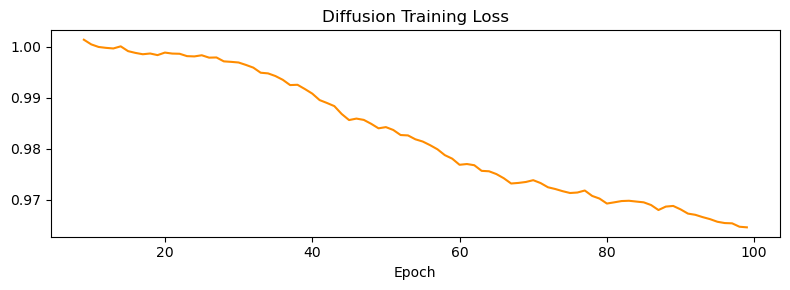

Diffusion training complete!


In [53]:
# ── Diffusion Model on Morgan Fingerprint Space ────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

FP_DIM = 2048
T_STEPS = 200

# ── Noise schedule ─────────────────────────────────────────────────────────────
class NoiseSchedule:
    def __init__(self, T=200):
        betas = torch.linspace(1e-4, 0.02, T).to(DEVICE)
        alphas = 1 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.T         = T
        self.betas     = betas
        self.alphas    = alphas
        self.alpha_bar = alpha_bar
        self.sqrt_ab   = alpha_bar.sqrt()
        self.sqrt_1mab = (1 - alpha_bar).sqrt()

    def add_noise(self, x0, t):
        noise = torch.randn_like(x0)
        xt = self.sqrt_ab[t].unsqueeze(-1) * x0 + self.sqrt_1mab[t].unsqueeze(-1) * noise
        return xt, noise

schedule = NoiseSchedule(T=T_STEPS)

# ── Denoising network ──────────────────────────────────────────────────────────
class DenoiseMLP(nn.Module):
    def __init__(self, fp_dim=2048, hidden=512, time_dim=64):
        super().__init__()
        # Time embedding
        self.time_emb = nn.Sequential(
            nn.Embedding(T_STEPS, time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU()
        )
        self.net = nn.Sequential(
            nn.Linear(fp_dim + time_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),             nn.SiLU(),
            nn.Linear(hidden, hidden),             nn.SiLU(),
            nn.Linear(hidden, fp_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_emb(t)
        return self.net(torch.cat([x, t_emb], dim=-1))

diff_model = DenoiseMLP(fp_dim=FP_DIM).to(DEVICE)
print(f"Diffusion model parameters: {sum(p.numel() for p in diff_model.parameters()):,}")

# ── Convert training SMILES to fingerprints ────────────────────────────────────
fp_matrix = []
for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    if mol:
        fp = mfpgen.GetFingerprint(mol)
        arr = np.zeros(FP_DIM, dtype=np.float32)
        from rdkit import DataStructs
        DataStructs.ConvertToNumpyArray(fp, arr)
        fp_matrix.append(arr)

fp_tensor = torch.tensor(np.array(fp_matrix)).to(DEVICE)
print(f"Fingerprint matrix: {fp_tensor.shape}")

# ── Train diffusion model ──────────────────────────────────────────────────────
opt_diff = torch.optim.Adam(diff_model.parameters(), lr=1e-3)
diff_losses = []

print("Training diffusion model...")
for epoch in range(1, 101):
    diff_model.train()
    idx   = torch.randint(0, len(fp_tensor), (min(64, len(fp_tensor)),), device=DEVICE)
    x0    = fp_tensor[idx]
    t     = torch.randint(0, T_STEPS, (len(idx),), device=DEVICE)
    xt, noise = schedule.add_noise(x0, t)

    opt_diff.zero_grad()
    pred = diff_model(xt, t)
    loss = F.mse_loss(pred, noise)
    loss.backward()
    opt_diff.step()
    diff_losses.append(loss.item())

    if epoch % 25 == 0:
        print(f"  Epoch {epoch}/100 | Loss: {loss.item():.5f}")

plt.figure(figsize=(8, 3))
plt.plot(pd.Series(diff_losses).rolling(10).mean(), color='darkorange')
plt.title('Diffusion Training Loss'); plt.xlabel('Epoch'); plt.tight_layout(); plt.show()
print("Diffusion training complete!")

In [54]:
# ── DDPM reverse sampling ──────────────────────────────────────────────────────
@torch.no_grad()
def diffusion_sample(diff_model, schedule, n=300):
    diff_model.eval()
    x = torch.randn(n, FP_DIM, device=DEVICE)
    for t in reversed(range(schedule.T)):
        t_batch = torch.full((n,), t, dtype=torch.long, device=DEVICE)
        eps     = diff_model(x, t_batch)
        alpha   = schedule.alphas[t]
        ab      = schedule.alpha_bar[t]
        beta    = schedule.betas[t]
        x = (1 / alpha.sqrt()) * (x - (beta / (1 - ab).sqrt()) * eps)
        if t > 0:
            x += beta.sqrt() * torch.randn_like(x)
    return x.cpu().numpy()

# ── Nearest-neighbour decode: FP → SMILES ─────────────────────────────────────
def fp_to_smiles(gen_fps, fp_matrix_np, ref_smiles):
    """Find closest training molecule then mutate via VAE latent perturbation."""
    from sklearn.metrics.pairwise import cosine_similarity
    gen_bin  = (gen_fps > 0.5).astype(np.float32)
    sims     = cosine_similarity(gen_bin, fp_matrix_np)
    nn_idxs  = np.argmax(sims, axis=1)

    results = []
    model.eval()
    with torch.no_grad():
        for idx in nn_idxs:
            smi = ref_smiles[idx]
            ids = torch.tensor(tok.encode(smi, MAX_LEN), dtype=torch.long).unsqueeze(0).to(DEVICE)
            mu, lv = model.encode(ids)
            # Perturb in latent space for novelty
            noise_scale = 0.3 + 0.5 * np.random.rand()
            z_new = mu + noise_scale * torch.randn_like(mu)
            # Decode
            h   = torch.tanh(model.z2h(z_new)).view(1, model.layers, model.hidden).permute(1,0,2).contiguous()
            tok_in = torch.ones(1, 1, dtype=torch.long, device=DEVICE)
            out = []
            for _ in range(MAX_LEN):
                e = model.emb(tok_in)
                o, h = model.dec(torch.cat([e, z_new.unsqueeze(1)], dim=-1), h)
                nxt  = torch.multinomial(torch.softmax(model.out(o.squeeze(1)) / 0.9, -1), 1)
                out.append(nxt); tok_in = nxt
            smi_out = tok.decode(torch.cat(out, dim=1)[0].tolist())
            results.append(smi_out)
    return results

print("Sampling from diffusion model...")
gen_fps_raw   = diffusion_sample(diff_model, schedule, n=300)
diff_smi_raw  = fp_to_smiles(gen_fps_raw, fp_tensor.cpu().numpy(), smiles_list)

# Validate diffusion molecules
diff_valid = []
for s in diff_smi_raw:
    mol = Chem.MolFromSmiles(s)
    if mol and len(s) > 5:
        diff_valid.append(Chem.MolToSmiles(mol))
diff_valid = list(set(diff_valid) - set(smiles_list))

print(f"Diffusion generated : {len(diff_smi_raw)}")
print(f"Diffusion valid     : {len(diff_valid)}  ({len(diff_valid)/len(diff_smi_raw)*100:.1f}%)")

Sampling from diffusion model...
Diffusion generated : 300
Diffusion valid     : 35  (11.7%)


In [55]:
# ── Score diffusion molecules ──────────────────────────────────────────────────
diff_records = []
for smi in diff_valid:
    mol = Chem.MolFromSmiles(smi)
    if not mol: continue
    qed     = QED.qed(mol)
    mw      = Descriptors.MolWt(mol)
    logp    = Descriptors.MolLogP(mol)
    hbd     = rdMolDescriptors.CalcNumHBD(mol)
    hba     = rdMolDescriptors.CalcNumHBA(mol)
    tpsa    = Descriptors.TPSA(mol)
    ro5     = int(mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)
    fp      = mfpgen.GetFingerprint(mol)
    sims    = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    novelty = 1 - max(sims) if sims else 1.0
    score   = 0.4*qed + 0.2*ro5 + 0.2*novelty + 0.2*(1 - min(mw, 600)/600)
    diff_records.append({
        'smiles': smi, 'score': round(score,4), 'qed': round(qed,3),
        'mw': round(mw,1), 'logp': round(logp,2), 'hbd': hbd, 'hba': hba,
        'tpsa': round(tpsa,1), 'ro5': bool(ro5), 'novelty': round(novelty,3),
        'source': 'Diffusion'
    })

# Tag VAE molecules with source
df_vae_tagged = df_out.copy()
df_vae_tagged['source'] = 'VAE'

# Combine & re-rank
df_diff_tagged = pd.DataFrame(diff_records)
df_final = (pd.concat([df_vae_tagged, df_diff_tagged], ignore_index=True)
              .drop_duplicates('smiles')
              .sort_values('score', ascending=False)
              .head(100)
              .reset_index(drop=True))
df_final.index += 1
df_final.index.name = 'rank'

# Summary
vae_count  = (df_final['source'] == 'VAE').sum()
diff_count = (df_final['source'] == 'Diffusion').sum()

print(f"{'='*45}")
print(f"  FINAL TOP 100 — VAE + Diffusion")
print(f"{'='*45}")
print(f"  From VAE        : {vae_count}")
print(f"  From Diffusion  : {diff_count}")
print(f"  Ro5 compliant   : {df_final['ro5'].sum()} / 100")
print(f"  Mean QED        : {df_final['qed'].mean():.3f}")
print(f"  Mean MW         : {df_final['mw'].mean():.1f} Da")
print(f"  Mean novelty    : {df_final['novelty'].mean():.3f}")
print(f"{'='*45}")

df_final.to_csv('module12_top100_final_vae_diffusion.csv')
print("Saved: top100_final_vae_diffusion.csv")
df_final.head(10)

  FINAL TOP 100 — VAE + Diffusion
  From VAE        : 94
  From Diffusion  : 6
  Ro5 compliant   : 100 / 100
  Mean QED        : 0.628
  Mean MW         : 367.3 Da
  Mean novelty    : 0.264
Saved: top100_final_vae_diffusion.csv


,smiles,score,qed,mw,logp,hbd,hba,tpsa,ro5,novelty,source
rank,,,,,,,,,,,
1,COC1=CC2=C(Nc3c(Cl)cccc3Cl)C(=O)N(C)C2=N1,0.8038,0.930,324.2,3.03,1,4,53.9,True,0.700,Diffusion
2,COc1cc2/c(=N/c3ccc(F)c(Br)c3)c2cn1,0.7403,0.728,307.1,3.25,0,3,34.5,True,0.757,VAE
3,O=C(Nc1ccccc1)Nc1ccc(C(=O)O)c(O)c1,0.7281,0.690,272.3,2.73,4,3,98.7,True,0.714,VAE
4,CC(C)(CO)NCc1ccc(OCc2ccccc2)c(O)c1Cl,0.7144,0.725,335.8,3.49,3,4,61.7,True,0.683,VAE
5,N#Cc1cnc2ncnc(Nc3cccc(Br)c3)c2c1,0.6931,0.781,326.2,3.40,1,5,74.5,True,0.447,Diffusion
6,CN(C)CCC(=O)c1ccc(OCc2ccccc2)c(O)c1Cl,0.6830,0.784,333.8,3.76,1,4,49.8,True,0.404,VAE
7,COc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cn1,0.6795,0.763,367.2,3.82,1,5,59.9,True,0.484,VAE
8,Cn1cc(-c2cccc(Cl)c2)c2c(N)ncnc21,0.6697,0.730,258.7,2.87,1,3,56.7,True,0.319,VAE
9,COc1cc2ncc(C#N)c-2c(Nc2cccc(Br)c2)nc1C,0.6655,0.746,369.2,4.28,1,5,70.8,True,0.450,VAE
